В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("tommykamaz/faces-dataset-small")

print("Path to dataset files:", path)

In [2]:
# для запуска на каггле
path = '../input/faces-dataset-small'

In [3]:
# TODO: resize images, convert them to tensors and build dataloader
def get_dataloader(image_size, batch_size):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """

  # transform = tt.Compose([
  #     tt.Resize(image_size),
  #     tt.CenterCrop(image_size),
  #     tt.ToTensor(),
  #     tt.Normalize(*stats)
  # ])

    # пытаюсь немного увеличить размер выборки, а то на обычной он быстро запоминает лица
  transform = tt.Compose([
    tt.Resize(image_size),
    tt.CenterCrop(image_size),
    tt.RandomHorizontalFlip(p=0.5),
    tt.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1), # Разное освещение
    tt.RandomPerspective(distortion_scale=0.05, p=0.2), # Небольшое искажение формы лица
    tt.ToTensor(),
    tt.Normalize(*stats)
  ])

  dataset = ImageFolder(root=path, transform=transform)
  print(f"Найдено изображений: {len(dataset)}")
  dataset_dl = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)

  return dataset_dl

In [4]:
#TODO: build dataloader and transfer it to device
image_size = 128
batch_size = 128
stats = [[0.5, 0.5, 0.5], [0.5, 0.5, 0.5]]

data = get_dataloader(image_size, batch_size)

Найдено изображений: 3143


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

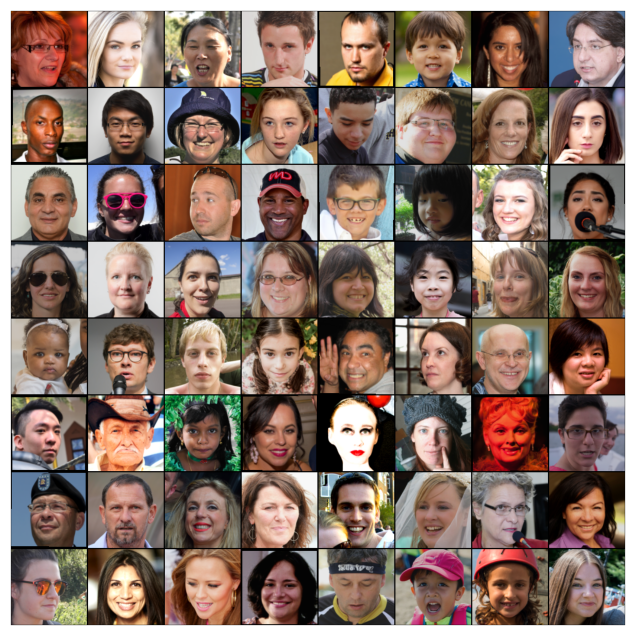

In [6]:
show_batch(data)

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device('cpu')

def to_cuda(data, device):
    if isinstance(data, (list,tuple)):
        return [to_cuda(x, device) for x in data]
    return data.to(device, non_blocking=True)

class ToCuda:
  def __init__(self, data, device):
    self.data = data
    self.device = device

  def __iter__(self):
    for batch in self.data:
      yield to_cuda(batch, self.device)

data = ToCuda(data, device)

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [7]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    # nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    # nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # nn.Dropout(0.3),

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    # nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    # nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1, bias=False),
    # nn.BatchNorm2d(1024),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(1024, 1, kernel_size=4, stride=1, padding=0, bias=False),

    nn.Flatten()
)

discriminator = to_cuda(discriminator, device)

In [8]:
# использую upsample+conv2d, чтобы избавиться от полос на сгенерированных картинках, которе получаются из-за ConvTranspose2d

latent_size = 128

generator = nn.Sequential(
    nn.ConvTranspose2d(latent_size, 1024, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(1024),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),

    # 2. 4x4 -> 8x8
    nn.Upsample(scale_factor=2),
    nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1, bias=False), # stride=1 !
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    # 3. 8x8 -> 16x16
    nn.Upsample(scale_factor=2),
    nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.Dropout(0.2), # Добавляем для борьбы с Mode Collapse

    nn.Upsample(scale_factor=2),
    nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1, bias=False),
    nn.Tanh()
)
generator = to_cuda(generator, device)

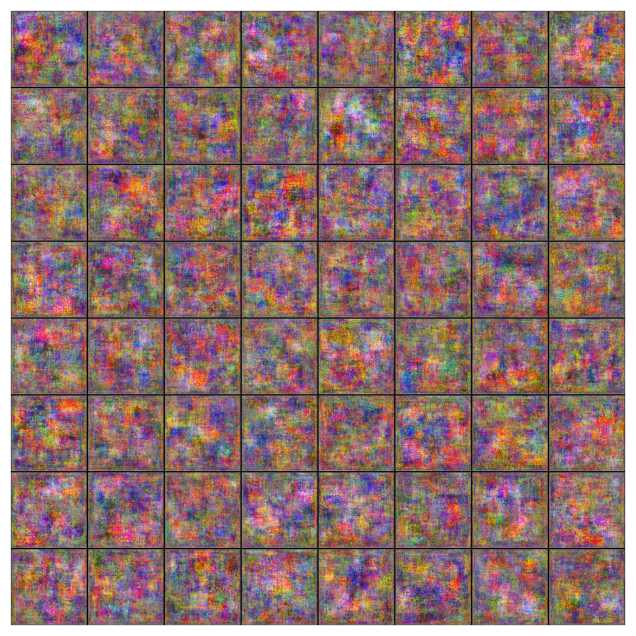

In [9]:
xb = torch.randn(batch_size, latent_size, 1, 1, device=device)
fake_images = generator(xb)
show_images(fake_images.cpu().detach())

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [10]:
lr = 0.0001
epochs = 50

model = {
    "discriminator": discriminator.to(device),
    "generator": generator.to(device)
}

criterion = {
    "discriminator": nn.BCEWithLogitsLoss(),
    "generator": nn.BCEWithLogitsLoss()
}

In [11]:
def fit(model, criterion, epochs, lr, start_idx=1):
    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []
    
    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(), 
                                          lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(),
                                      lr=lr, betas=(0.5, 0.999))
    }
    
    for epoch in range(epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []
        for real_images, _ in tqdm(data):
            cur_batch_size = real_images.size(0)
            optimizer["discriminator"].zero_grad()

            # Я добавляю шум к фото, который с увеличением эпохи уменьшается. Так генератор в начале получает фору, чтобы попробовать больше типажей лиц
            coef = max(0.1 * (1 - epoch/epochs), 0.01)
            noise = torch.randn_like(real_images) * coef
            real_preds = model["discriminator"](real_images + noise)
            real_targets = torch.ones(real_images.size(0), 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(torch.sigmoid(real_preds)).item()
            
            latent = torch.randn(cur_batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            noise = torch.randn_like(fake_images) * coef
            fake_targets = torch.zeros(cur_batch_size, 1, device=device)
            fake_preds = model["discriminator"](fake_images.detach() + noise)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(torch.sigmoid(fake_preds)).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())

            optimizer["generator"].zero_grad()
            latent = torch.randn(cur_batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)
            
            preds = model["discriminator"](fake_images)
            targets = torch.ones(cur_batch_size, 1, device=device)
            loss_g = criterion["generator"](preds, targets)
            
            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())
            
        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))
        
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, 
            losses_g[-1], losses_d[-1], real_scores[-1], fake_scores[-1]))
    
    return losses_g, losses_d, real_scores, fake_scores

In [12]:
history = fit(model, criterion, epochs, lr)

0it [00:00, ?it/s]

Epoch [1/50], loss_g: 0.7852, loss_d: 1.3564, real_score: 0.5956, fake_score: 0.5434


0it [00:00, ?it/s]

Epoch [2/50], loss_g: 0.8040, loss_d: 1.2977, real_score: 0.5937, fake_score: 0.5249


0it [00:00, ?it/s]

...

Epoch [48/50], loss_g: 1.0029, loss_d: 1.0738, real_score: 0.7251, fake_score: 0.4959


0it [00:00, ?it/s]

Epoch [49/50], loss_g: 0.9565, loss_d: 1.0611, real_score: 0.7449, fake_score: 0.4868


0it [00:00, ?it/s]

Epoch [50/50], loss_g: 0.9114, loss_d: 1.0405, real_score: 0.7447, fake_score: 0.4824


In [13]:
loss_generator, loss_discriminator, scores_real, scores_fake = history

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

Text(0.5, 1.0, 'Losses')

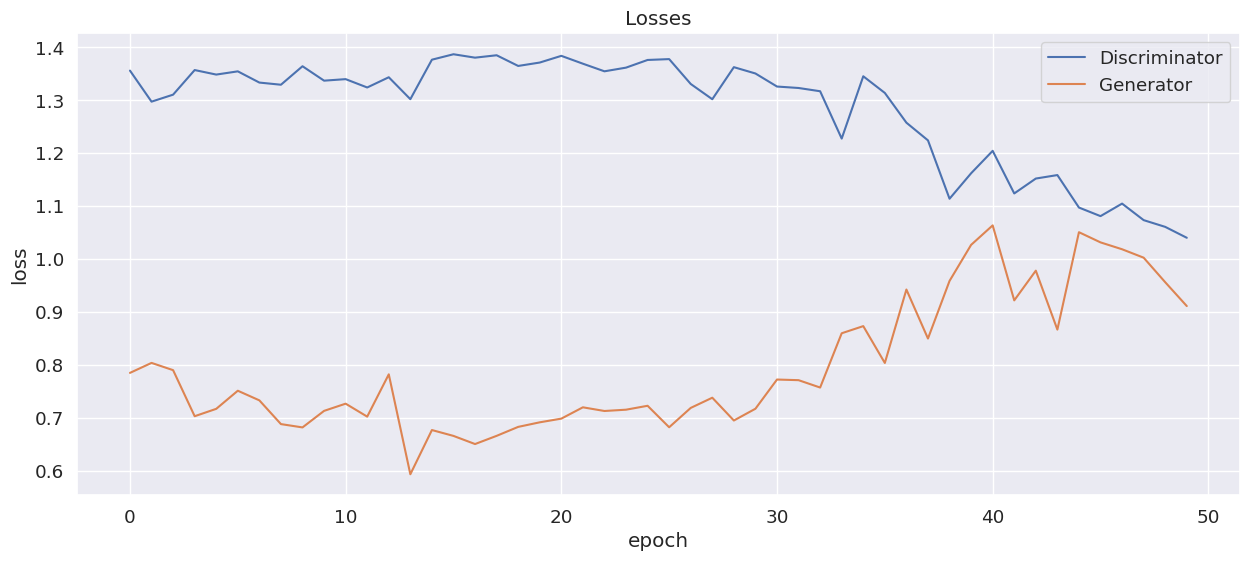

In [14]:
plt.figure(figsize=(15, 6))
plt.plot(loss_discriminator, '-')
plt.plot(loss_generator, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses')

Text(0.5, 1.0, 'Scores')

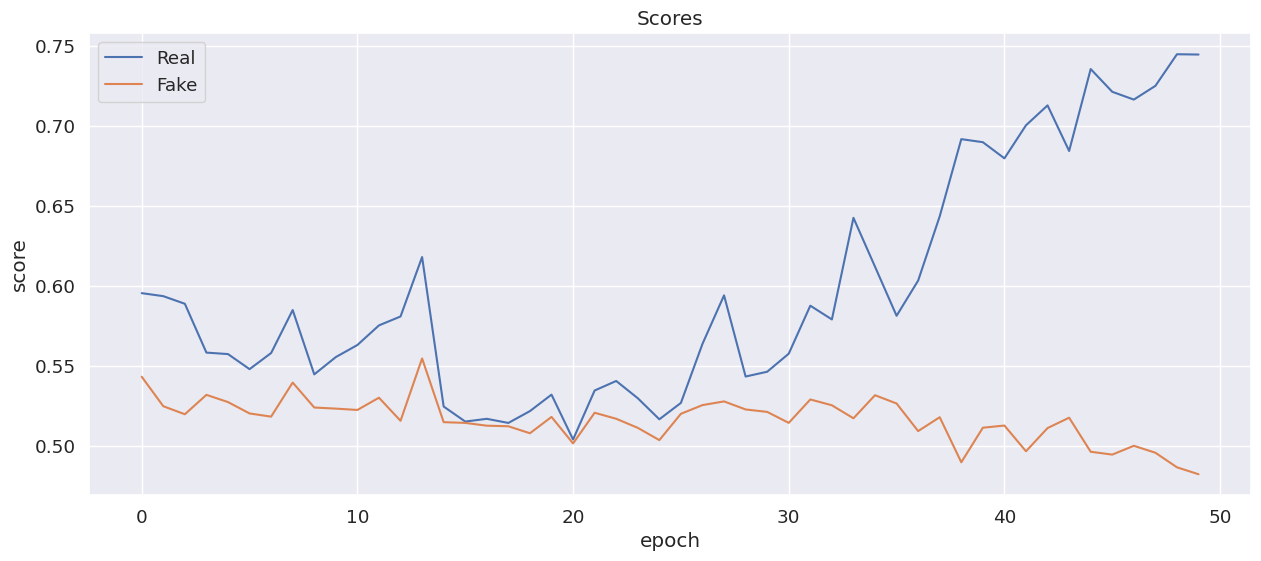

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(scores_real, '-')
plt.plot(scores_fake, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real', 'Fake'])
plt.title('Scores')

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [16]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [17]:
def show_images(generated):
  fig, ax = plt.subplots(figsize=(8, 8))
  ax.set_xticks([])
  ax.set_yticks([])
  ax.imshow(make_grid(denorm(generated.cpu().detach()[:64]), nrow=8).permute(1, 2, 0))
  plt.show()

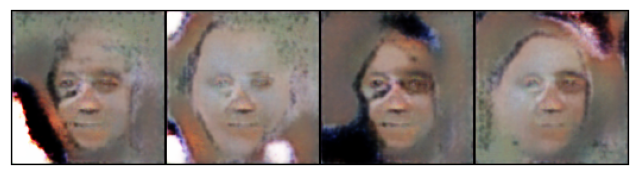

In [18]:
show_images(fake_images)

Как вам качество получившихся изображений?

Не очень, но лица разные хотя бы (по крайней мере видно, что поворот головы разный).

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [19]:
torch.cuda.empty_cache()

In [29]:
# буду считать accuacy на 1000 изображений, так как иначе выдает cuda out of memory
count = 3143
batch_size=128
fake_images_list = []

model["generator"].eval()

with torch.no_grad():
    for i in range(0, count, batch_size):
        current_batch_size = min(batch_size, count - i)
        latent_batch = torch.randn(current_batch_size, latent_size, 1, 1, device=device)
        fake_images = model["generator"](latent_batch)
        
        batch = fake_images.view(current_batch_size, -1).cpu().numpy()
        fake_images_list.append(batch)

fake_images = np.concatenate(fake_images_list, axis=0)

print(fake_images.shape)

(3143, 49152)


In [30]:
real_images_list = []
cur = 0

for real_images, _ in data:
    needed = count - cur
    if needed <= 0:
        break
    
    if real_images.size(0) > needed:
        real_images = real_images[:needed]
        
    batch = real_images.view(real_images.size(0), -1).cpu().numpy()
    real_images_list.append(batch)
    
    cur += real_images.size(0)

real_images = np.concatenate(real_images_list, axis=0)

print(real_images.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


(3143, 49152)


In [31]:
# сжимаю с помощью PCA, иначе очень долго работает
from sklearn.decomposition import PCA

X = np.concatenate([real_images, fake_images], axis=0)
y = np.concatenate([np.ones(count), np.zeros(count)])

pca = PCA(n_components=100)
X_reduced = pca.fit_transform(X)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=1)
loo = LeaveOneOut()

y_true = []
y_pred = []
    
for train_index, test_index in tqdm(loo.split(X_reduced), total=len(X_reduced)):
    X_train, X_test = X_reduced[train_index], X_reduced[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    knn.fit(X_train, y_train)
    y_pred.append(knn.predict(X_test)[0])
    y_true.append(y_test[0])
    
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

  0%|          | 0/6286 [00:00<?, ?it/s]

Accuracy: 0.9251


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

accuracy=0.92, значит классификатор почти идеально отличает сгенерированные картинки от реальных. Следовательно, генератор все еще слабый.
Идеальный accuracy=0.5, так как это значит, что классификатор по сути просто угадывает, реальная это картинка или нет (и у него всегда вероятность только 50%, что картинка реальная).

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

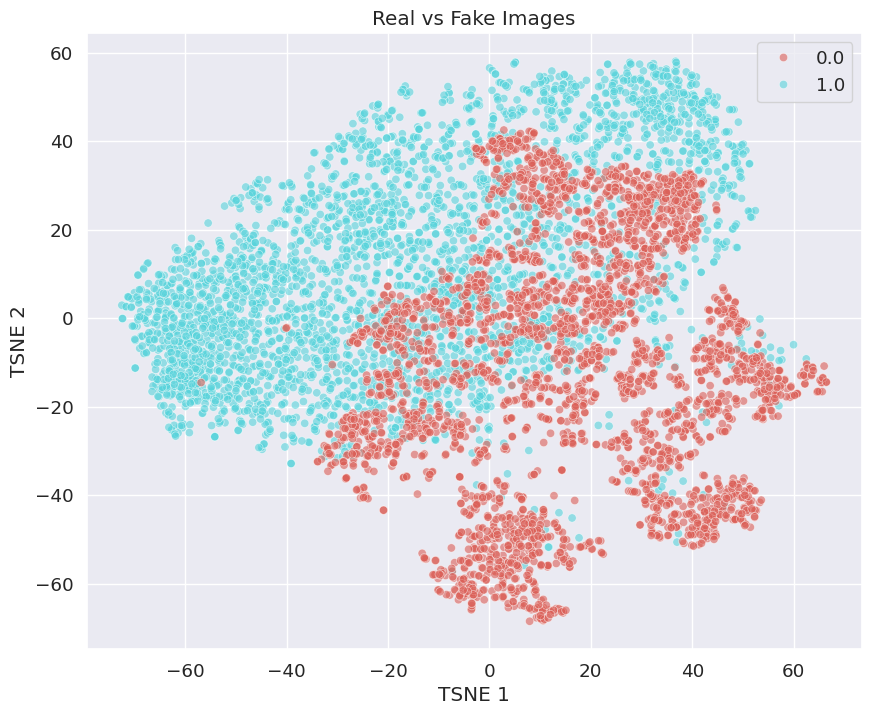

In [34]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1) 
X_tsne = tsne.fit_transform(X_reduced)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.6
)
plt.title("Real vs Fake Images")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()

Прокомментируйте получившийся результат:

Видим пересечение real и fake, значит генератор частично нашел область распределения реальных данных. Еще фейки как бы разделены на 3 части, значит, что генератор делает свои картинки на основе 3 типажей лиц.